Install the `nomad` package from GitHub

In [1]:
# %pip uninstall -y nomad
# %pip install git+https://github.com/Watts-Lab/nomad.git@expansion#egg=nomad

In [ ]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy.random as npr
import random
from shapely.geometry import box
from pprint import pprint

import nomad.city_gen as cg
from nomad.city_gen import City, Building, Street
import nomad.traj_gen as tg
from nomad.traj_gen import Agent, Population
import nomad.stop_detection as sd

from nomad.constants import DEFAULT_SPEEDS, FAST_SPEEDS, SLOW_SPEEDS, DEFAULT_STILL_PROBS
from nomad.constants import FAST_STILL_PROBS, SLOW_STILL_PROBS, ALLOWED_BUILDINGS

import os
os.environ['TZ'] = 'UTC'

import pdb

Create City

In [ ]:
class RandomCityGenerator:
    def __init__(self, width, height, street_spacing=5, park_ratio=0.1, home_ratio=0.4, work_ratio=0.3, retail_ratio=0.2, seed=None):
        if seed:
            npr.seed(seed)

        self.width = width
        self.height = height
        self.street_spacing = street_spacing  # Determines regular intervals for streets
        self.park_ratio = park_ratio
        self.home_ratio = home_ratio
        self.work_ratio = work_ratio
        self.retail_ratio = retail_ratio

        self.city = City(dimensions=(width, height))
        self.occupied = set()
        self.streets = self.generate_streets()
        self.block_types = self.assign_block_types()
        self.building_sizes = {
            'home': [(2, 2), (1, 2), (2, 1), (1, 1), (2, 3), (3, 2)],
            'work': [(2, 2), (2, 3), (3, 2), (4, 4), (3, 3), (4, 2), (2, 4)],
            'retail': [(2, 2), (2, 3), (3, 2), (4, 4), (3, 3), (2, 4), (4, 2)],
            'park': [(6, 6), (5, 5), (4, 4)]
        }

    def generate_streets(self):
        """Predefine streets in a systematic grid pattern."""
        streets = set()
        for x in range(0, self.width, self.street_spacing):
            for y in range(self.height):
                streets.add((x, y))
        for y in range(0, self.height, self.street_spacing):
            for x in range(self.width):
                streets.add((x, y))
        return streets
    
    def assign_block_types(self):
        """Assigns each block a type based on the defined ratios."""
        block_types = {}
        for x in range(0, self.width, self.street_spacing):
            for y in range(0, self.height, self.street_spacing):
                block_types[(x, y)] = random.choices(
                    ['home', 'work', 'retail', 'park'],
                    weights=[self.home_ratio, self.work_ratio, self.retail_ratio, self.park_ratio],
                    k=1
                )[0]
        return block_types
    
    def fill_block(self, block_x, block_y, block_type):
        """Fills an entire block with buildings, ensuring randomness and full coverage."""
        available_space = [(x, y) for y in range(block_y, min(block_y + self.street_spacing, self.height))
                           for x in range(block_x, min(block_x + self.street_spacing, self.width))
                           if (x, y) not in self.occupied and (x, y) not in self.streets]
        
        random.shuffle(self.building_sizes[block_type])  # Shuffle sizes for randomness
        attempts = 0  # Termination condition to prevent infinite loops
        max_attempts = len(available_space) * 2
        
        while available_space and attempts < max_attempts:
            size = random.choice(self.building_sizes[block_type])
            random.shuffle(available_space)  # Randomize placement within the block
            for x, y in available_space:
                if all((x + dx, y + dy) in available_space for dx in range(size[0]) for dy in range(size[1])):
                    door = self.get_adjacent_street((x, y))
                    if door and isinstance(door, tuple) and door in self.city.streets:
                        self.occupied.update((x + dx, y + dy) for dx in range(size[0]) for dy in range(size[1]))
                        self.city.add_building(building_type=block_type, door=door,
                                              bbox=box(x, y, x + size[0], y + size[1]))
                        available_space = [(px, py) for px, py in available_space if (px, py) not in self.occupied]
                        break  # Place one building at a time and reattempt filling
            attempts += 1  # Increment attempt counter
    
    def get_adjacent_street(self, location):
        """Finds the closest predefined street to assign as the door, ensuring it’s within bounds."""
        if not location or not isinstance(location, tuple):
            return None
        x, y = location
        possible_streets = [(x + dx, y + dy) for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]]
        valid_streets = [street for street in possible_streets if street in self.streets and 0 <= street[0] < self.width and 0 <= street[1] < self.height]
        return valid_streets[0] if valid_streets else None

    def place_buildings_in_blocks(self):
        """Fills each block completely with buildings using proportional distribution."""
        for (block_x, block_y), block_type in self.block_types.items():
            self.fill_block(block_x, block_y, block_type)
    
    def generate_city(self):
        """Generates a systematically structured city where blocks are fully occupied with buildings."""
        self.place_buildings_in_blocks()
        self.city.get_street_graph()
        return self.city if self.city.buildings else None

In [ ]:
width, height = 50, 50
city_generator = RandomCityGenerator(width, height, street_spacing=5, park_ratio=0.05, home_ratio=0.4, work_ratio=0.3, retail_ratio=0.25, seed=100)
clustered_city = city_generator.generate_city()

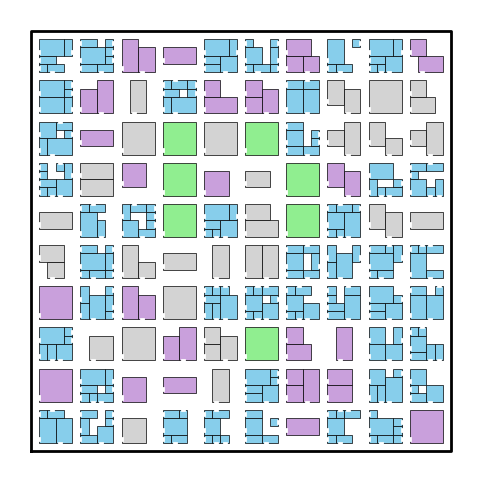

In [19]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(6, 6))
plt.box(on=False)

clustered_city.plot_city(ax, doors=True, address=False)

# remove axis labels and ticks
ax.set_yticklabels([])
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_yticks([])

plt.show()